In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from statsmodels.api import Logit, add_constant
import random
from scipy.stats import chi2_contingency

In [2]:
df=pd.read_csv("Health Insurance Dataset.csv")
df

,age,sex,bmi,children,smoker,region,charges,Level,score
0,19,female,27.900,0,yes,southwest,16884.92400,B,72
1,18,male,33.770,1,no,southeast,1725.55230,C,69
2,28,male,33.000,3,no,southeast,4449.46200,B,90
3,33,male,22.705,0,no,northwest,21984.47061,A,47
4,32,male,28.880,0,no,northwest,3866.85520,C,76
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,B,90
1334,18,female,31.920,0,no,northeast,2205.98080,C,83
1335,18,female,36.850,0,no,southeast,1629.83350,B,61
1336,21,female,25.800,0,no,southwest,2007.94500,D,76


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
 7   Level     1338 non-null   object 
 8   score     1338 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 94.2+ KB


In [4]:
df.describe()

,age,bmi,children,charges,score
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,65.967115
std,14.049960,6.098187,1.205493,12110.011237,15.235684
min,18.000000,15.960000,0.000000,1121.873900,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,56.250000
50%,39.000000,30.400000,1.000000,9382.033000,66.000000
75%,51.000000,34.693750,2.000000,16639.912515,77.000000
max,64.000000,53.130000,5.000000,63770.428010,100.000000


In [9]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
Level          5
score         81
dtype: int64

Number of outliers: 0


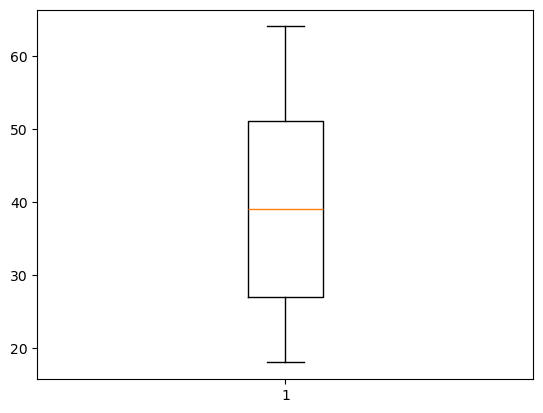

In [11]:
fig, ax = plt.subplots()
ax.boxplot(df['age'])
q1 = np.quantile(df['age'], 0.25)
q3 = np.quantile(df['age'], 0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
outliers = [x for x in df['age'] if x < lower_bound or x > upper_bound]
num_outliers = len(outliers)
print("Number of outliers:", num_outliers)
plt.show()

Number of outliers: 9


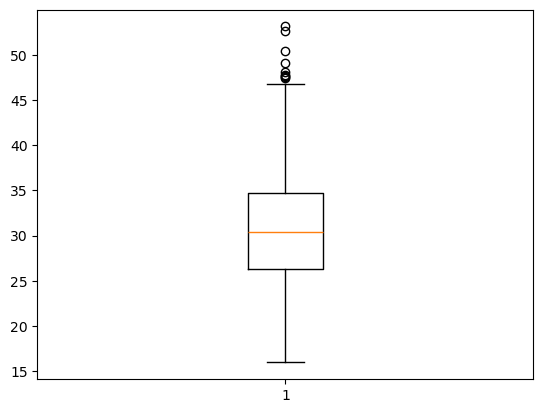

In [13]:
fig, ax = plt.subplots()
ax.boxplot(df['bmi'])
q1 = np.quantile(df['bmi'], 0.25)
q3 = np.quantile(df['bmi'], 0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
outliers = [x for x in df['bmi'] if x < lower_bound or x > upper_bound]
num_outliers = len(outliers)
print("Number of outliers:", num_outliers)
plt.show()

In [15]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [17]:
df['sex'].value_counts()*100/len(df['sex'])

sex
male      50.523169
female    49.476831
Name: count, dtype: float64

<Axes: xlabel='sex'>

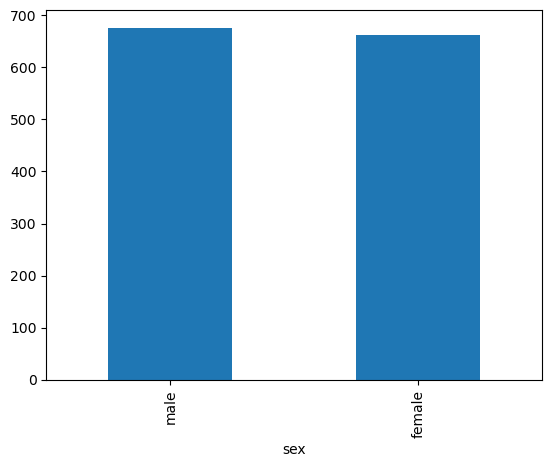

In [19]:
df['sex'].value_counts().plot.bar()

In [21]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [23]:
df['smoker'].value_counts()*100/len(df['smoker'])

smoker
no     79.521674
yes    20.478326
Name: count, dtype: float64

<Axes: xlabel='smoker'>

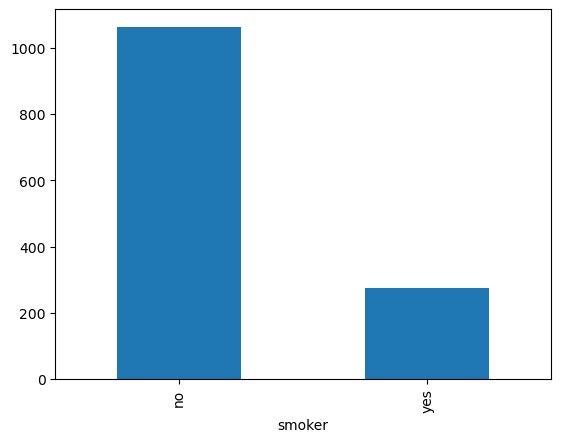

In [25]:
df['smoker'].value_counts().plot.bar()

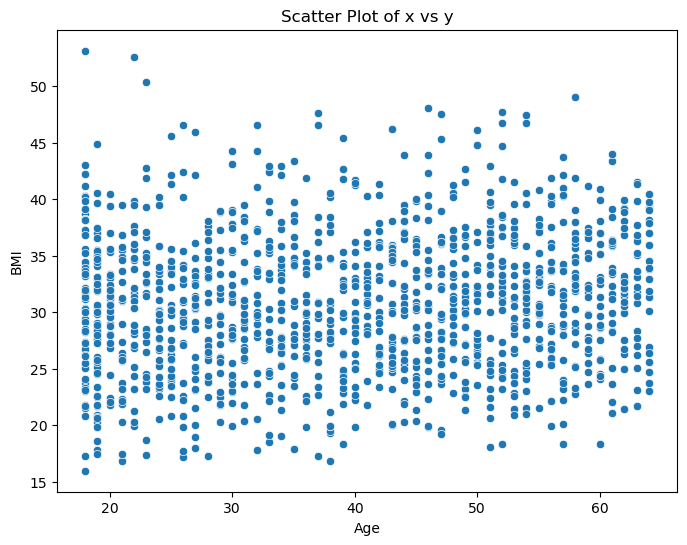

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='bmi', data=df)
plt.title('Scatter Plot of x vs y')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

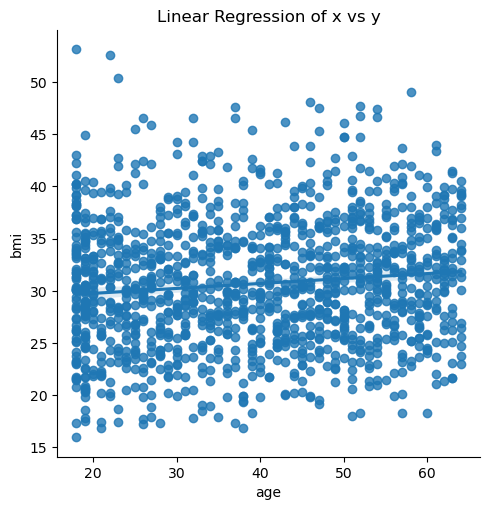

In [29]:
sns.lmplot(x='age', y='bmi', data=df)
plt.title('Linear Regression of x vs y')
plt.show()

In [31]:
cross_tab = pd.crosstab(df['sex'], df['smoker'])
print(cross_tab)

smoker   no  yes
sex             
female  547  115
male    517  159


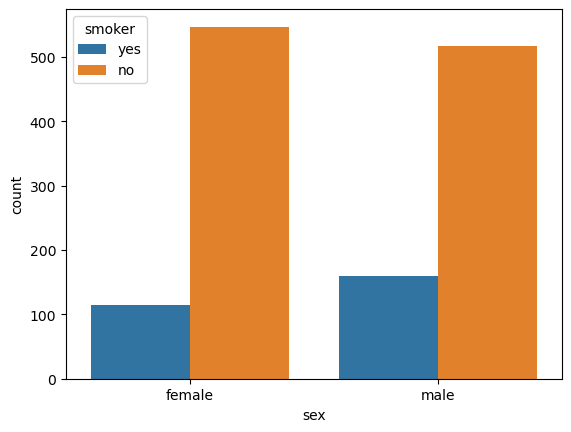

In [49]:
sns.countplot(x='sex', hue='smoker', data=df)
plt.show()

In [35]:
male_bmi = df[df['sex'] == 'male']['bmi']
female_bmi = df[df['sex'] == 'female']['bmi']
t_statistic, p_value = stats.ttest_ind(male_bmi, female_bmi)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
alpha = 0.05 
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in BMI between males and females.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in BMI between males and females.")

T-statistic: 1.696752635752224
P-value: 0.08997637178984932
Fail to reject the null hypothesis: There is no significant difference in BMI between males and females.


In [47]:
sex = df['sex']
smoker = df['smoker']
xtabs = pd.crosstab(sex, smoker)
print(xtabs)
print("\n")

smoker   no  yes
sex             
female  547  115
male    517  159




In [45]:
stat, p, dof, expected = chi2_contingency(xtabs)

alpha = 0.05
print("The chi statistic is " + str(stat))
print("p value is " + str(p))
print("Degrees of Freedom are " + str(dof))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

The chi statistic is 7.39291081459996
p value is 0.0065481435035807025
Degrees of Freedom are 1
Dependent (reject H0)
